# 03 — Análisis de Efectos Secundarios por Componentes

Este notebook ejecuta el pipeline completo de análisis y validación
para el Enfoque 3: Efectos Secundarios por Componentes.

Genera las siguientes visualizaciones:
1. Top efectos secundarios globales
2. Componentes con mayor diversidad de efectos
3. Heatmap normalizado componente × efecto
4. Boxplot de efectos por número de componentes
5. Detalle de top efectos por componente
6. Histograma de distribución de n_efectos

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().resolve()
while not (project_root / "src").exists() and project_root != project_root.parent:
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.load_data import load_medicine_data
from src.enfoque_03_efectos_secundarios_componentes.cleaning import run_cleaning_pipeline
from src.enfoque_03_efectos_secundarios_componentes.transform import run_transform_pipeline
from src.enfoque_03_efectos_secundarios_componentes.analysis import run_analysis_pipeline
from src.enfoque_03_efectos_secundarios_componentes.validation import run_validation_pipeline

# 1. Cargar datos raw
df_raw = load_medicine_data(download_if_missing=False)
print(f"Dataset cargado: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")

# 2. Limpieza
df_clean = run_cleaning_pipeline(df_raw, save=False)

# 3. Transformaciones
df_long, crosstab, crosstab_norm = run_transform_pipeline(
    df_clean, min_observaciones=5, top_n_efectos=30, save=False
)

Dataset cargado: 11,825 filas × 9 columnas
INICIO DEL PIPELINE DE LIMPIEZA  [Enfoque 3]
[eliminar_duplicados] Filas antes: 11825 | Eliminados: 84 | Filas después: 11741
[añadir_columnas_derivadas] Columnas generadas: componentes, efectos_secundarios, manufacturer, n_componentes, n_efectos
[añadir_columnas_derivadas] Distribución por número de componentes:
    1 componente(s)  ->  7019 medicamentos
    2 componente(s)  ->  3569 medicamentos
    3 componente(s)  ->   929 medicamentos
    4 componente(s)  ->   147 medicamentos
    5 componente(s)  ->    51 medicamentos
    6 componente(s)  ->    16 medicamentos
    7 componente(s)  ->     7 medicamentos
    8 componente(s)  ->     2 medicamentos
    9 componente(s)  ->     1 medicamentos
[flag_anomalias] Registros sin componentes: 0
[flag_anomalias] Registros sin efectos secundarios: 0
-------------------------------------------------------
Forma final del DataFrame: (11741, 16)
INICIO DEL PIPELINE DE TRANSFORMACIONES  [Enfoque 3]
[explot

In [2]:
# 4. Validación de integridad
reporte = run_validation_pipeline(df_raw, df_clean)
print(f"\nEsquema válido: {reporte['esquema']['esquema_valido']}")
print(f"Filas eliminadas en limpieza: {reporte['shapes']['filas_eliminadas']}")

INICIO DEL PIPELINE DE VALIDACIÓN  [Enfoque 3]

[1/4] Verificando checksum MD5...
[verificar_checksum] Medicine_Details.csv
    MD5     : 93656e73e4e8fbf7dd8da9ecfab7ce07
    Tamaño  : 4,360,239 bytes
    Estado  : SIN_REFERENCIA

[2/4] Validando esquema del DataFrame raw...
[validar_esquema] Estado: INVÁLIDO
    Tipos incorrectos   : {'Medicine Name': {'esperado': 'object', 'real': 'str'}, 'Composition': {'esperado': 'object', 'real': 'str'}, 'Uses': {'esperado': 'object', 'real': 'str'}, 'Side_effects': {'esperado': 'object', 'real': 'str'}, 'Image URL': {'esperado': 'object', 'real': 'str'}, 'Manufacturer': {'esperado': 'object', 'real': 'str'}}

[3/4] Comparando shapes antes/después de limpieza...
[comparar_shapes]
    Filas raw           : 11,825
    Filas limpias       : 11,741
    Filas eliminadas    : 84 (0.71%)
    Columnas raw        : 9
    Columnas clean      : 16
    Columnas nuevas     : ['anomalia_componentes', 'anomalia_efectos', 'componentes', 'efectos_secundarios', 'm

INICIO DEL PIPELINE DE ANÁLISIS  [Enfoque 3]

[1/6] Generando top efectos secundarios globales...


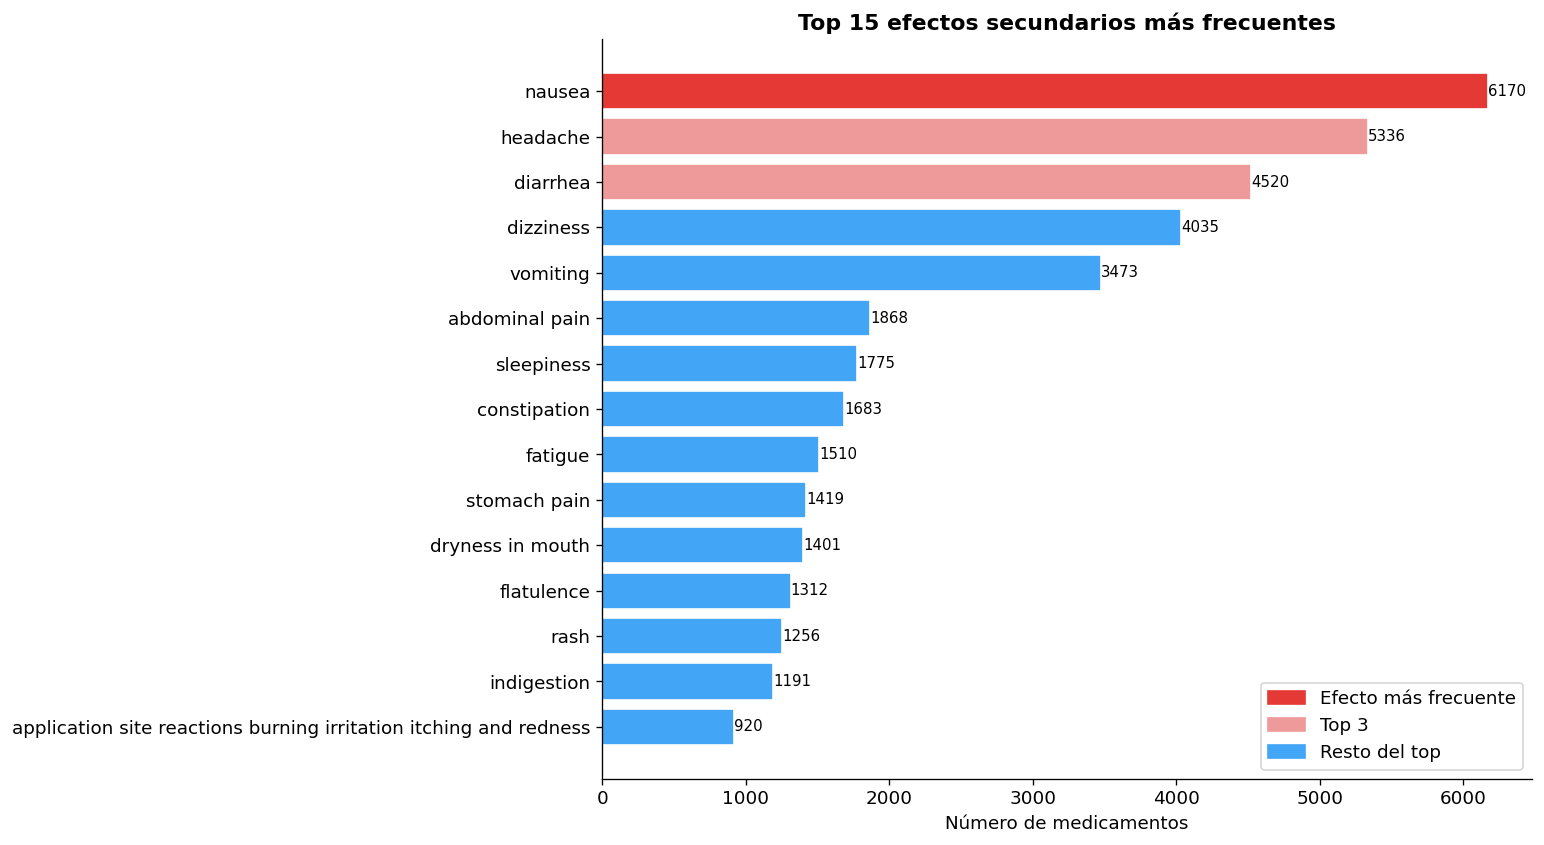

[analysis] Figura guardada: E:\Programación\ProgramacionParaLaCienciaDeDatos\SCY1101-Exp1-Drug-Data-Analysis\outputs\figures\e03_top_efectos_globales.png
[analysis] Tabla guardada: E:\Programación\ProgramacionParaLaCienciaDeDatos\SCY1101-Exp1-Drug-Data-Analysis\outputs\tables\e03_top_efectos_globales.csv

[2/6] Generando componentes por diversidad de efectos...


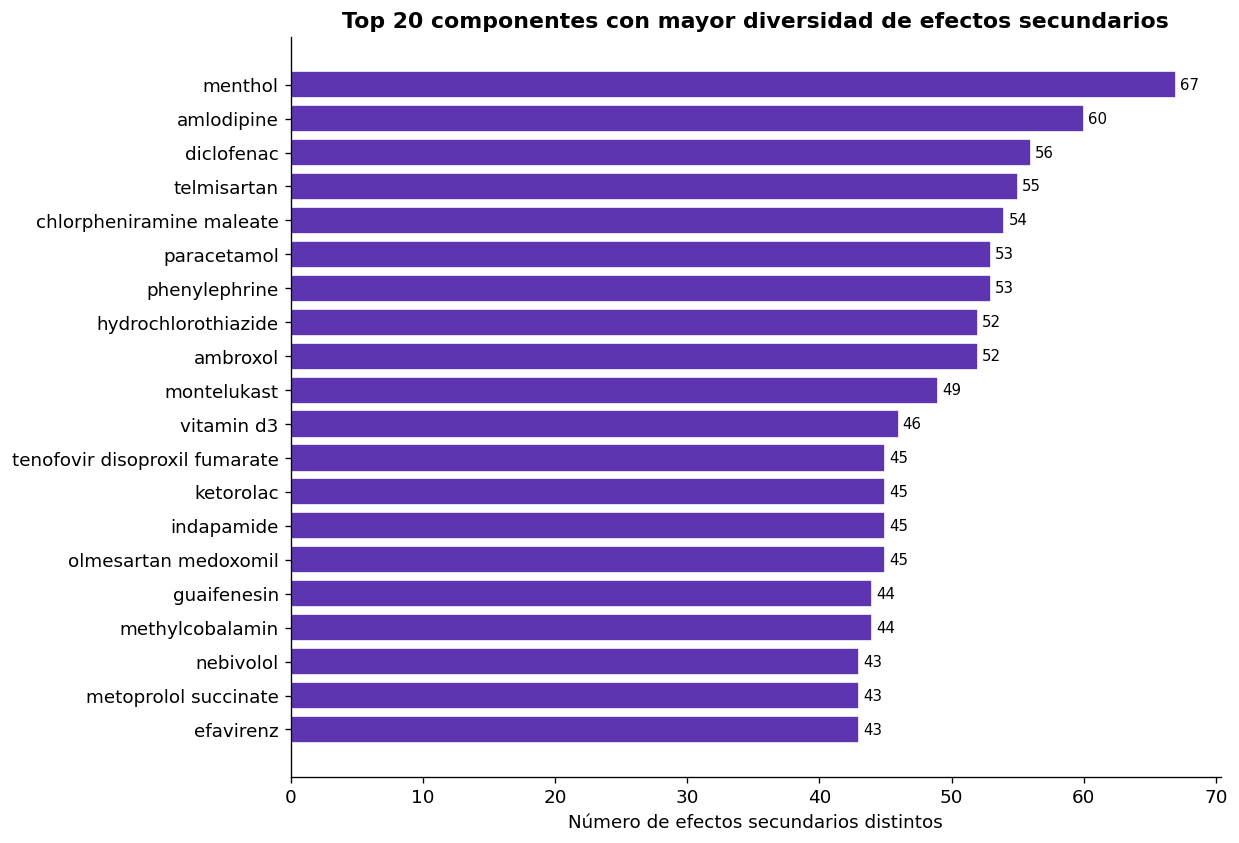

[analysis] Figura guardada: E:\Programación\ProgramacionParaLaCienciaDeDatos\SCY1101-Exp1-Drug-Data-Analysis\outputs\figures\e03_componentes_por_diversidad_efectos.png
[analysis] Tabla guardada: E:\Programación\ProgramacionParaLaCienciaDeDatos\SCY1101-Exp1-Drug-Data-Analysis\outputs\tables\e03_componentes_por_diversidad_efectos.csv

[3/6] Generando heatmap componente × efecto (normalizado)...


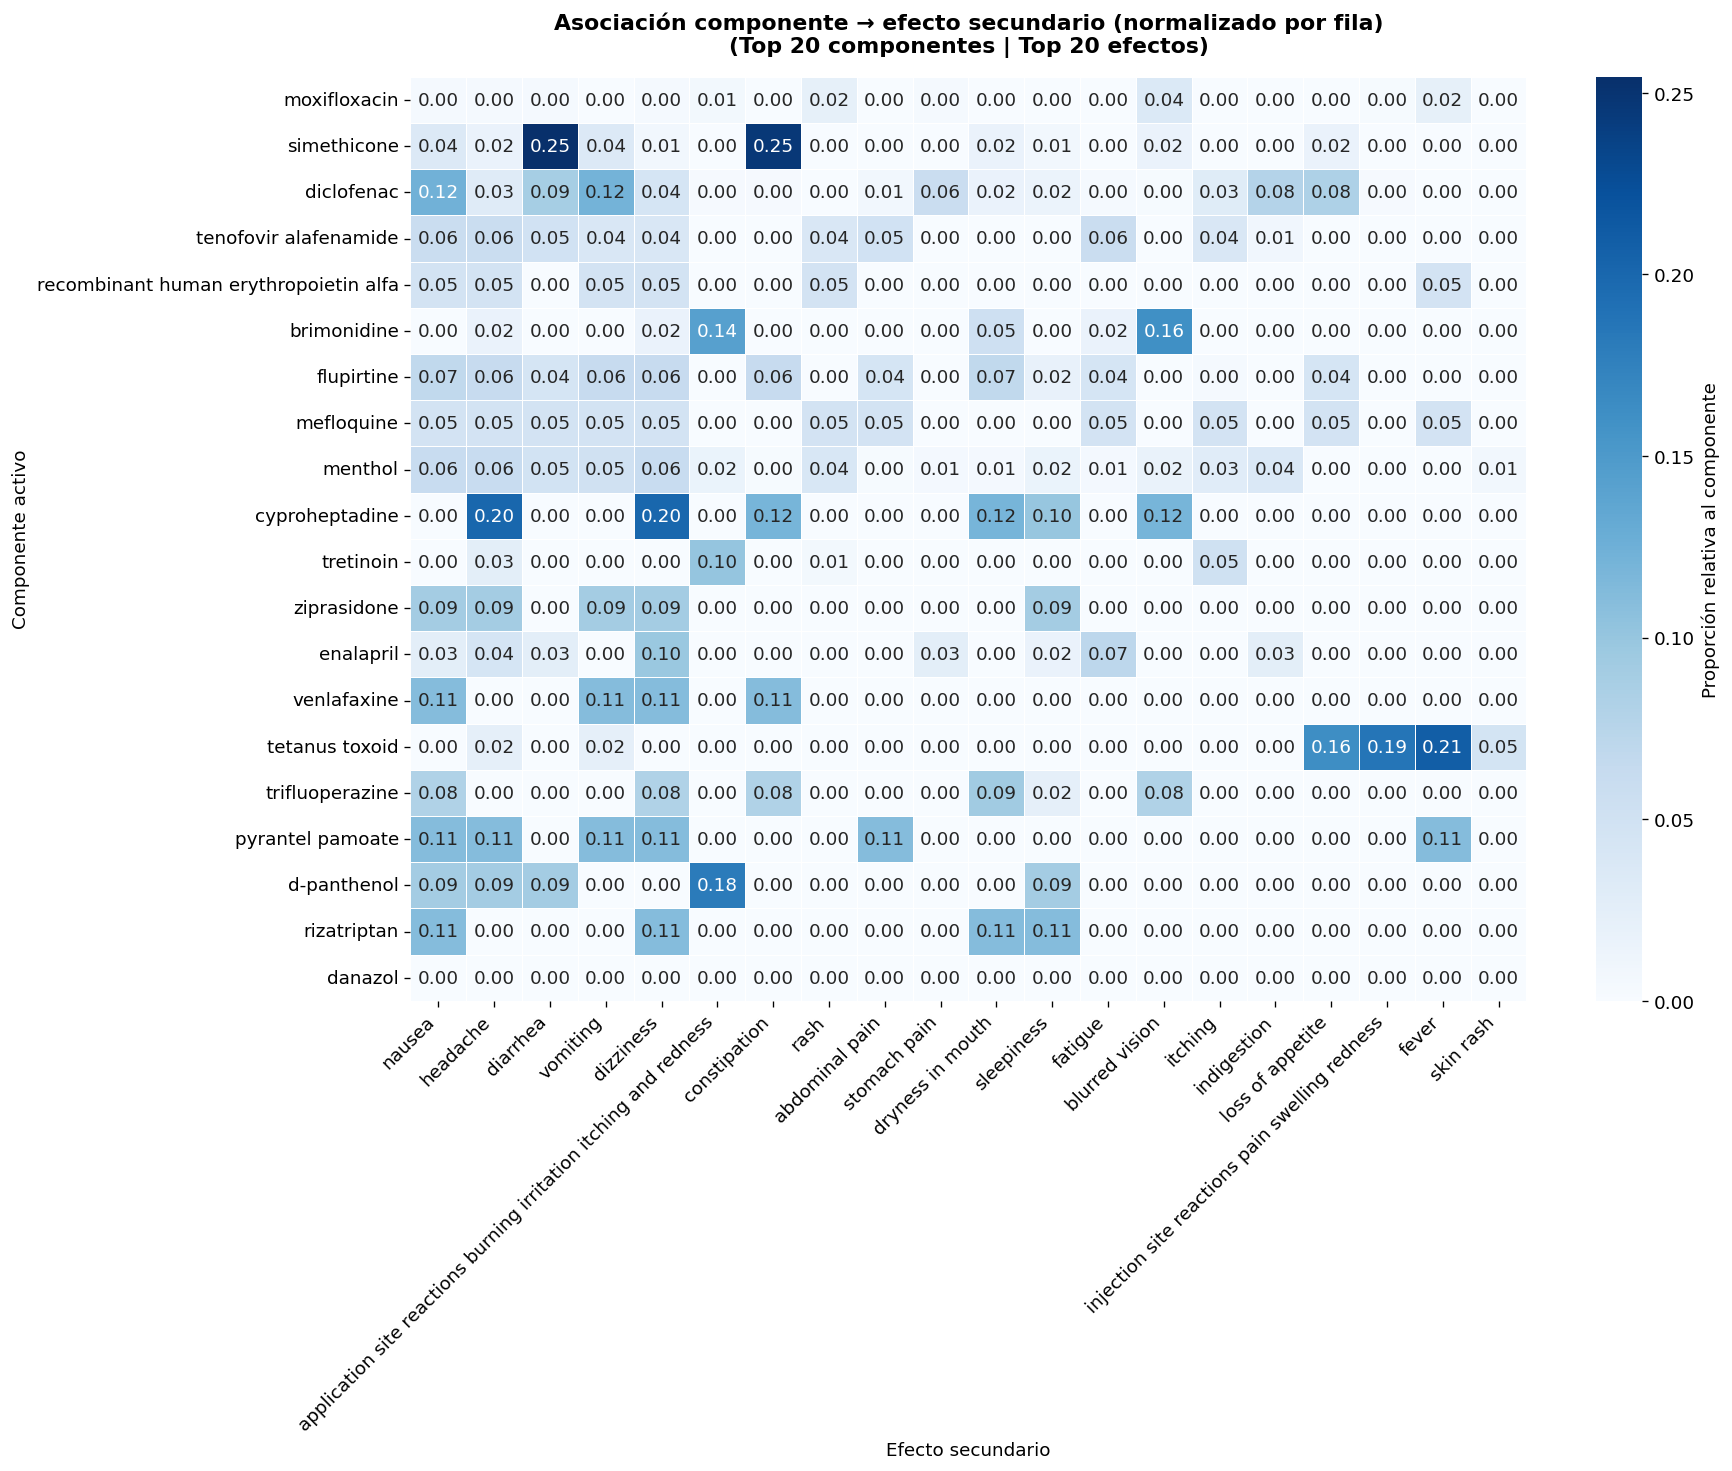

[analysis] Figura guardada: E:\Programación\ProgramacionParaLaCienciaDeDatos\SCY1101-Exp1-Drug-Data-Analysis\outputs\figures\e03_heatmap_componente_efecto_norm.png

[4/6] Generando boxplot de efectos por número de componentes...


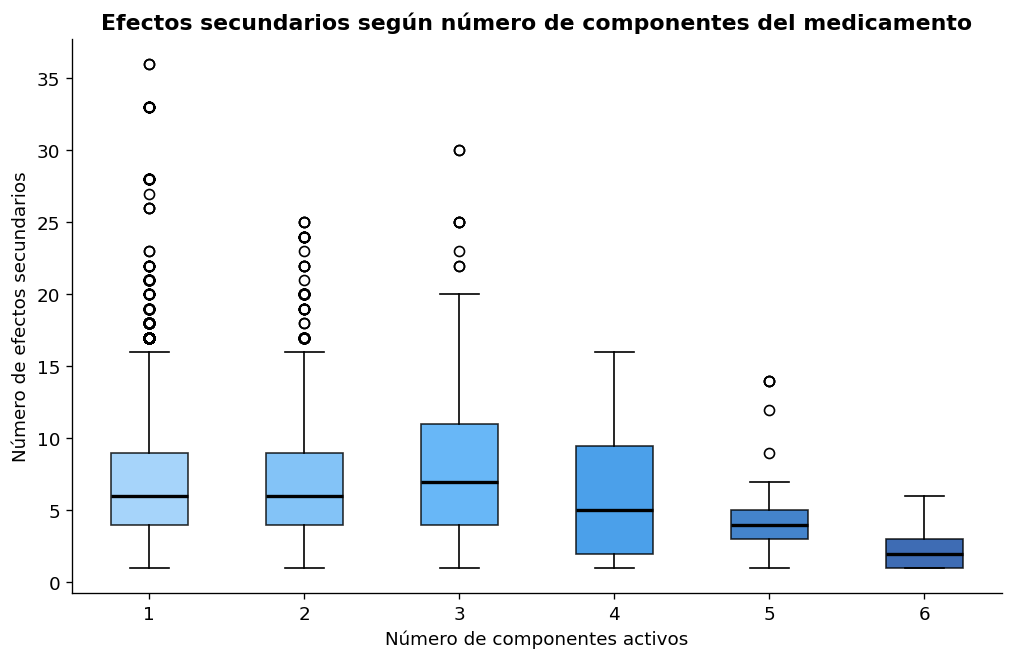

[analysis] Figura guardada: E:\Programación\ProgramacionParaLaCienciaDeDatos\SCY1101-Exp1-Drug-Data-Analysis\outputs\figures\e03_boxplot_efectos_por_n_componentes.png

[5/6] Generando detalle de top efectos por componente...


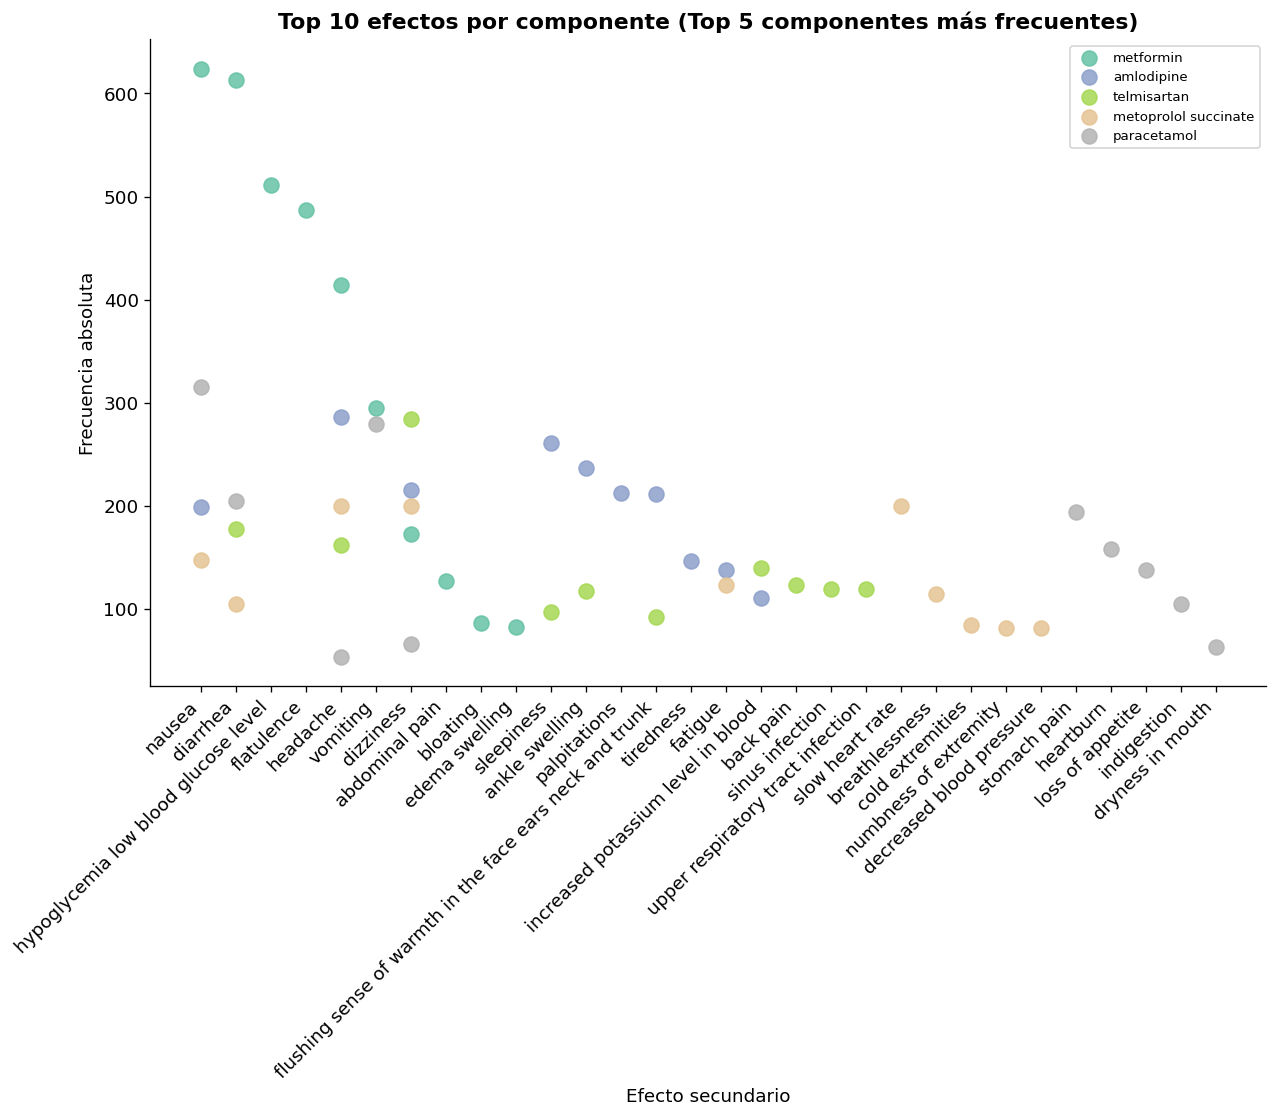

[analysis] Figura guardada: E:\Programación\ProgramacionParaLaCienciaDeDatos\SCY1101-Exp1-Drug-Data-Analysis\outputs\figures\e03_top_efectos_por_componente_detalle.png
[analysis] Tabla guardada: E:\Programación\ProgramacionParaLaCienciaDeDatos\SCY1101-Exp1-Drug-Data-Analysis\outputs\tables\e03_top_efectos_por_componente_detalle.csv

[6/6] Generando histograma de distribución de n_efectos...


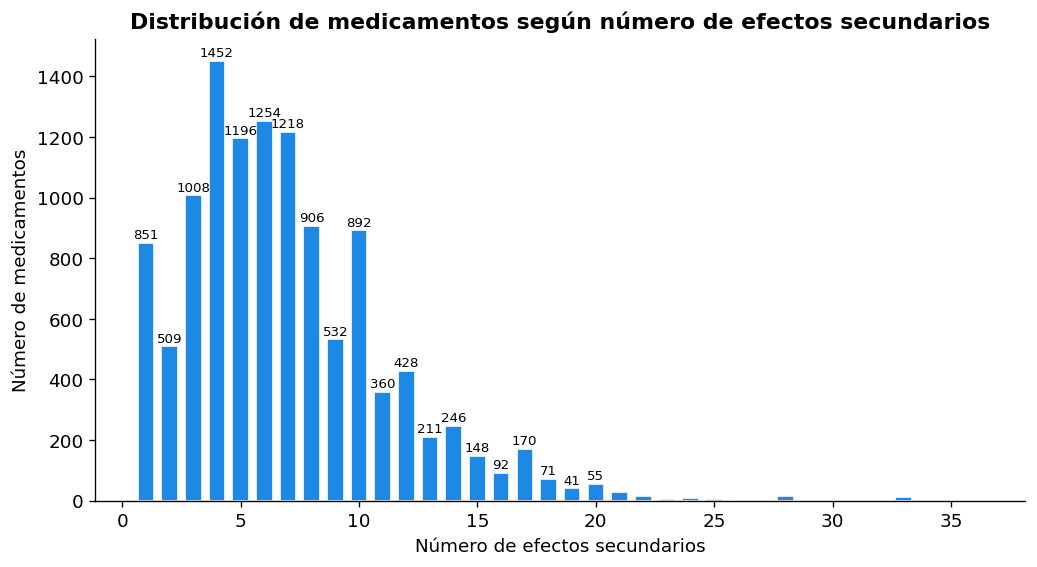

[analysis] Figura guardada: E:\Programación\ProgramacionParaLaCienciaDeDatos\SCY1101-Exp1-Drug-Data-Analysis\outputs\figures\e03_histograma_n_efectos.png

ANÁLISIS COMPLETO  [Enfoque 3]
Figuras guardadas en : E:\Programación\ProgramacionParaLaCienciaDeDatos\SCY1101-Exp1-Drug-Data-Analysis\outputs\figures
Tablas guardadas en  : E:\Programación\ProgramacionParaLaCienciaDeDatos\SCY1101-Exp1-Drug-Data-Analysis\outputs\tables


In [3]:
# 5. Análisis y visualizaciones
run_analysis_pipeline(df_clean, df_long, crosstab, crosstab_norm)